# EDA — Dataset Emosi Markus Erelius

Dataset berisi teks kutipan Marcus Aurelius yang sudah dilabeli dengan 8 emosi.  
EDA ini menjawab 3 pertanyaan bisnis yang paling fundamental sebelum membangun model klasifikasi.

---
## Setup

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
import re

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.facecolor': 'white'})

# Warna per emosi (konsisten di semua chart)
COLORS = {
    'netral':'#6B7280', 'senang':'#F59E0B', 'sedih':'#3B82F6',
    'marah':'#EF4444',  'takut': '#8B5CF6', 'jijik':'#10B981',
    'kaget':'#F97316',  'cape': '#6366F1'
}
ORDER = ['netral','senang','sedih','marah','takut','jijik','kaget','cape']

# ⬆️ Upload dataset_markus_erelius_clean.csv ke Colab sebelum jalankan ini
df = pd.read_csv('dataset_markus_erelius_clean.csv')
df['word_count']  = df['text'].str.split().str.len()
df['char_length'] = df['text'].str.len()

print(f'Jumlah data : {len(df)}')
print(f'Kolom       : {df.columns.tolist()}')
df.head(5)

Jumlah data : 1598
Kolom       : ['label', 'text', 'word_count', 'char_length']


,label,text,word_count,char_length
0,netral,marcus aurelius mengingatkan: kita hidup hanya...,15,115
1,cape,"terimalah tanpa kesombongan, lepaskan tanpa pe...",9,77
2,jijik,ini adalah tanda kesempurnaan karakter - mengh...,22,174
3,marah,kata marcus aurelius: seberapa banyak waktu ya...,23,165
4,senang,marcus aurelius mengingatkan: hidup singkat - ...,19,127


---
## Q1 — Apakah jumlah data tiap emosi sudah cukup dan merata?

**Kenapa penting:** Model klasifikasi bisa bias ke kelas yang datanya jauh lebih banyak.  
Kalau tidak merata, perlu teknik balancing sebelum training.

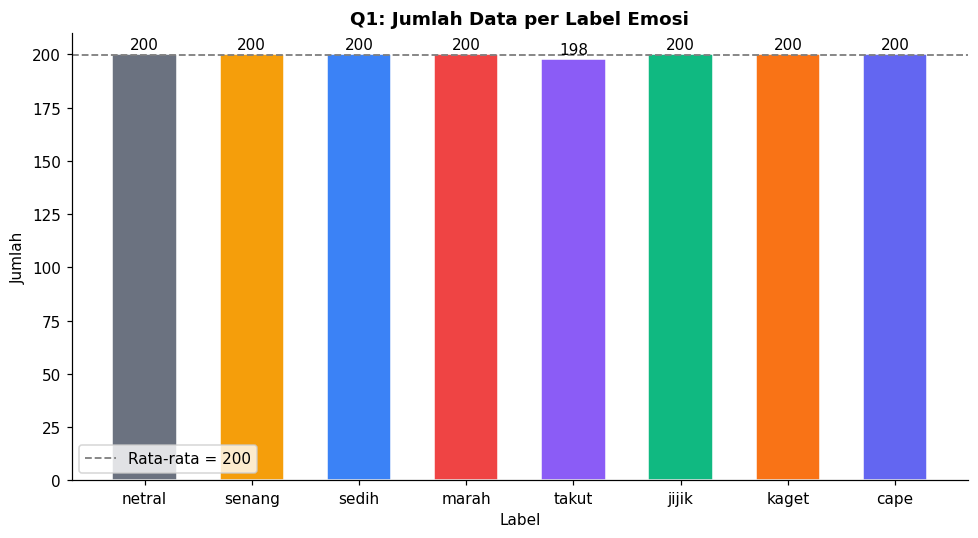

Distribusi label:
        jumlah  persen
label                 
netral     200    12.5
senang     200    12.5
sedih      200    12.5
marah      200    12.5
takut      198    12.4
jijik      200    12.5
kaget      200    12.5
cape       200    12.5

Selisih max-min: 2 data
→ Dataset hampir SEIMBANG, tidak perlu oversampling/undersampling.


In [7]:
counts = df['label'].value_counts().reindex(ORDER)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(counts.index, counts.values,
              color=[COLORS[l] for l in counts.index],
              width=0.6, edgecolor='white')

# Label angka di atas tiap bar
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

ax.axhline(counts.mean(), color='gray', linestyle='--', linewidth=1.2,
           label=f'Rata-rata = {counts.mean():.0f}')
ax.set_title('Q1: Jumlah Data per Label Emosi', fontweight='bold')
ax.set_xlabel('Label'); ax.set_ylabel('Jumlah')
ax.legend(); plt.tight_layout(); plt.show()

print('Distribusi label:')
print(counts.to_frame('jumlah').assign(persen=lambda x: (x['jumlah']/len(df)*100).round(1)))
print(f'\nSelisih max-min: {counts.max()-counts.min()} data')
print('→ Dataset hampir SEIMBANG, tidak perlu oversampling/undersampling.')

---
## Q2 — Apakah panjang teks berbeda-beda antar emosi?

**Kenapa penting:** Kalau panjang teks bervariasi ekstrem antar label, ini bisa jadi  
sinyal (fitur tambahan) untuk model, atau bisa mengganggu jika kita pakai model berbasis panjang teks.

/tmp/ipykernel_575/1237867862.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_groups, labels=ORDER, patch_artist=True,


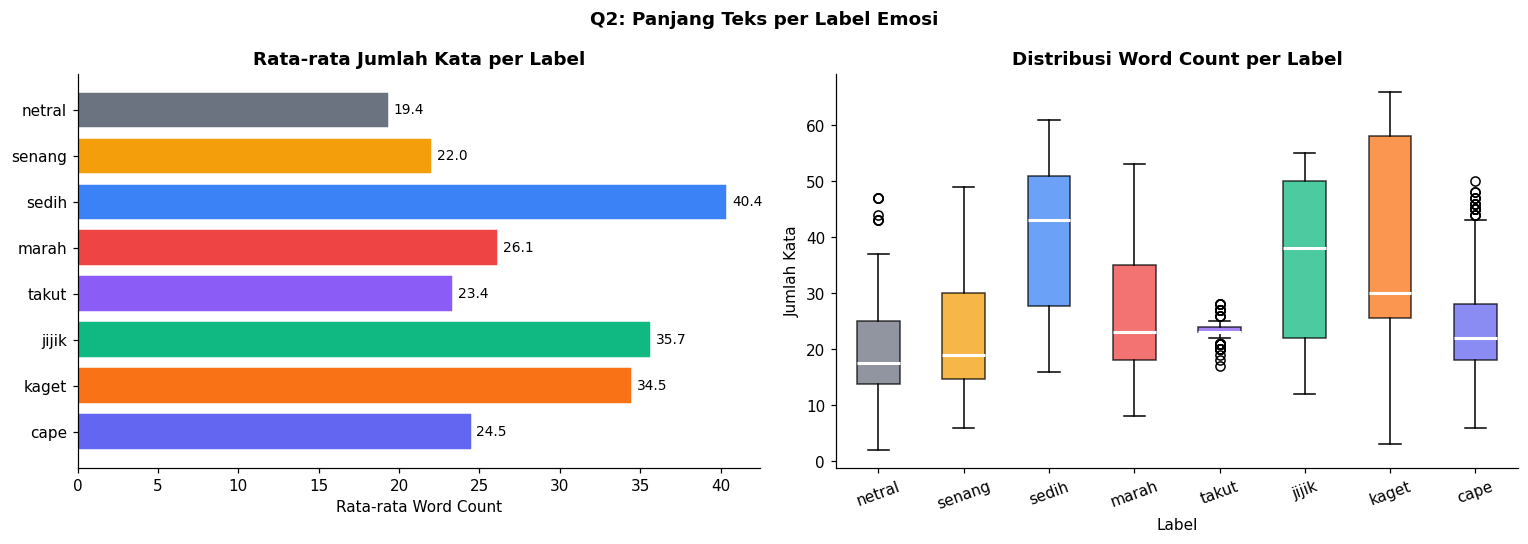

Statistik word count per label:
        mean  min  max
label                 
netral  19.4    2   47
senang  22.0    6   49
sedih   40.4   16   61
marah   26.1    8   53
takut   23.4   17   28
jijik   35.7   12   55
kaget   34.5    3   66
cape    24.5    6   50

→ SEDIH & JIJIK cenderung panjang; NETRAL & SENANG lebih singkat.
→ Word count bisa dijadikan fitur numerik tambahan saat training model.


In [8]:
wc_mean = df.groupby('label')['word_count'].mean().reindex(ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rata-rata jumlah kata per label
bars = axes[0].barh(wc_mean.index, wc_mean.values,
                    color=[COLORS[l] for l in wc_mean.index],
                    edgecolor='white')
for bar, val in zip(bars, wc_mean.values):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=9)
axes[0].set_title('Rata-rata Jumlah Kata per Label', fontweight='bold')
axes[0].set_xlabel('Rata-rata Word Count')
axes[0].invert_yaxis()

# Boxplot distribusi word count
data_groups = [df[df['label']==l]['word_count'].values for l in ORDER]
bp = axes[1].boxplot(data_groups, labels=ORDER, patch_artist=True,
                     medianprops=dict(color='white', linewidth=2))
for patch, label in zip(bp['boxes'], ORDER):
    patch.set_facecolor(COLORS[label])
    patch.set_alpha(0.75)
axes[1].set_title('Distribusi Word Count per Label', fontweight='bold')
axes[1].set_xlabel('Label'); axes[1].set_ylabel('Jumlah Kata')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Q2: Panjang Teks per Label Emosi', fontweight='bold')
plt.tight_layout(); plt.show()

print('Statistik word count per label:')
print(df.groupby('label')['word_count'].agg(['mean','min','max']).round(1).reindex(ORDER))
print('\n→ SEDIH & JIJIK cenderung panjang; NETRAL & SENANG lebih singkat.')
print('→ Word count bisa dijadikan fitur numerik tambahan saat training model.')

---
## Q3 — Kata apa yang paling sering muncul per emosi?

**Kenapa penting:** Kalau ada kata yang dominan di satu emosi dan jarang di emosi lain,  
model akan lebih mudah memisahkan kelas tersebut. Kalau kata-katanya tumpang tindih,  
model akan kesulitan dan butuh representasi yang lebih kaya (misal: embedding).

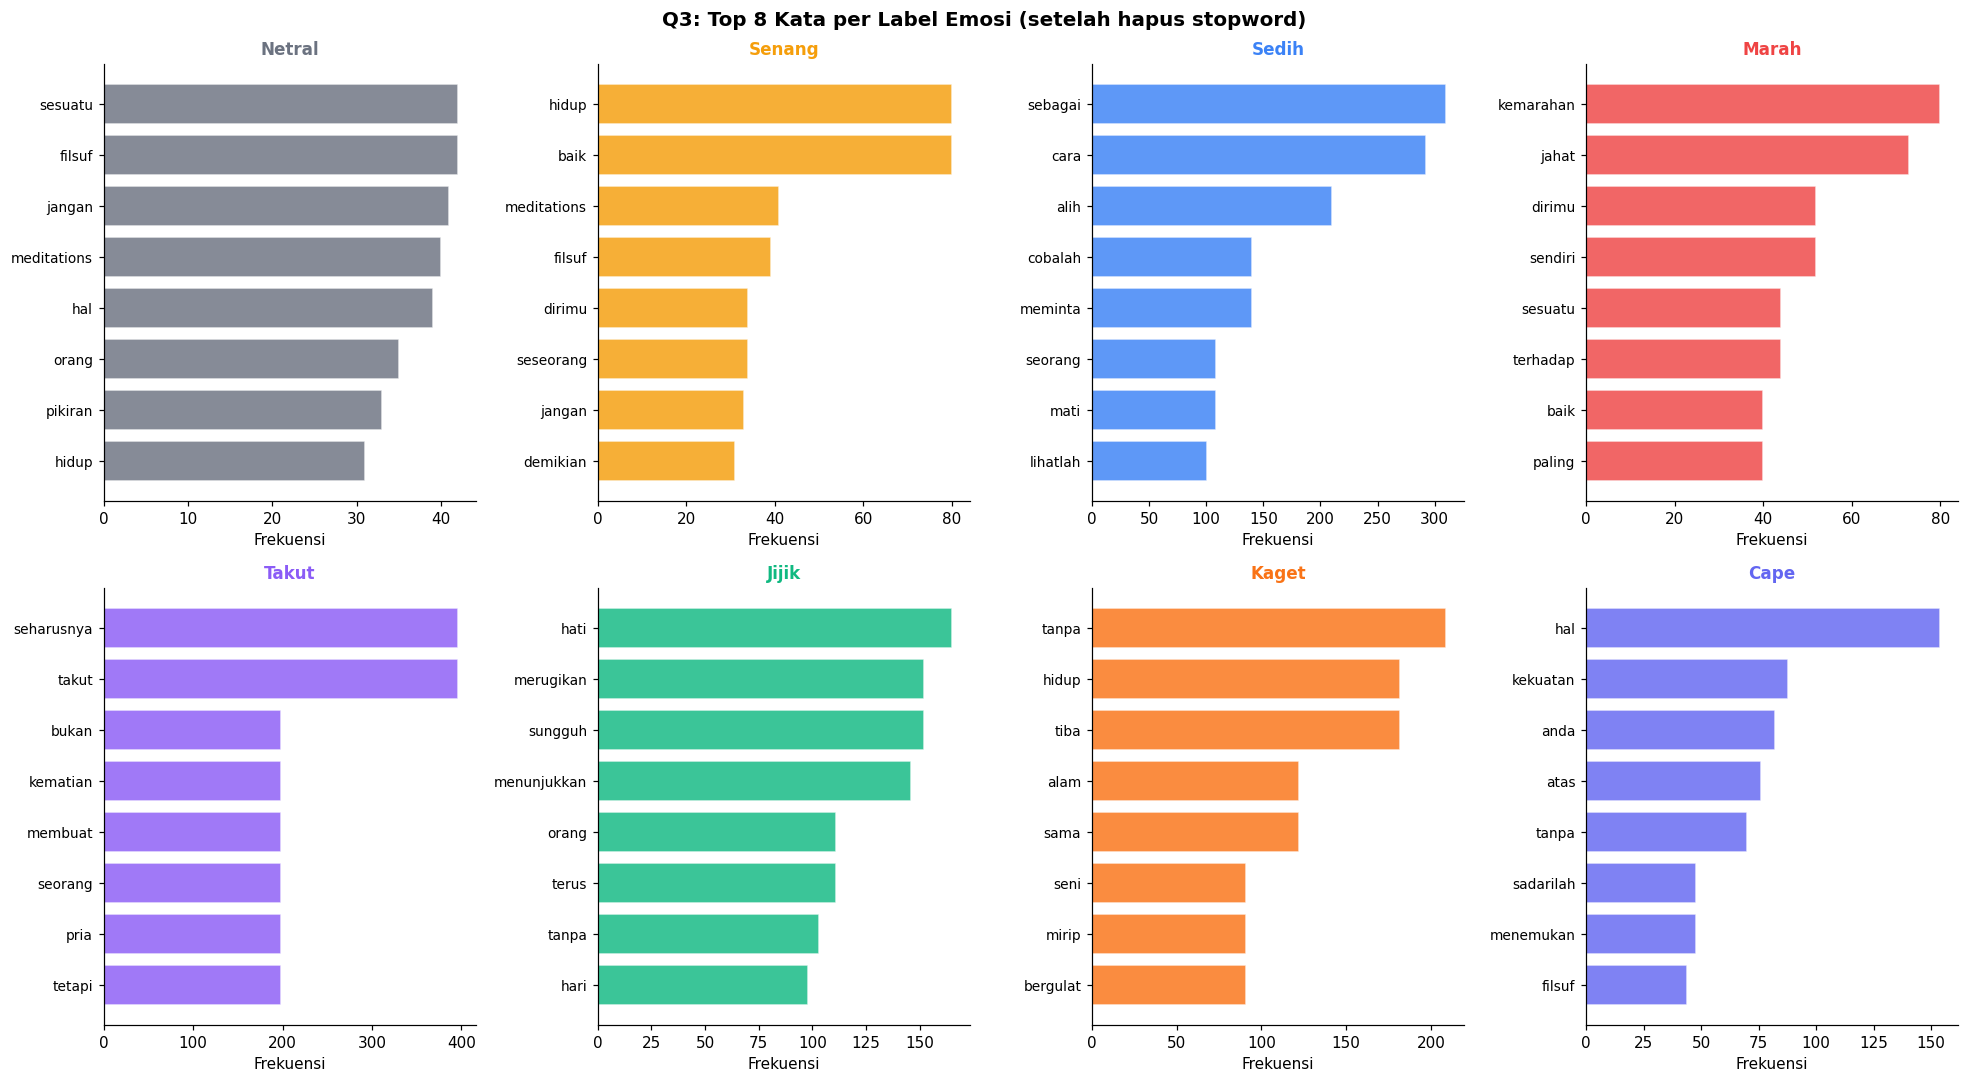

→ Lihat kata-kata yang unik per emosi — itu sinyal kuat untuk model.
→ Kata yang muncul di banyak emosi sekaligus sebaiknya difilter atau diberi bobot lebih rendah (TF-IDF).


In [9]:
STOPWORDS = {'yang','dan','di','ke','dari','ini','itu','adalah','dengan','untuk',
             'pada','tidak','akan','sudah','ada','juga','karena','apa','atau',
             'kamu','aku','saya','mereka','kita','dia','kata','marcus','aurelius',
             'pesan','seperti','setiap','dalam','jadi','semua','lagi','tentang',
             'begitu','bisa','lebih','sangat','bila','jika','tapi','namun','serta',
             'bahwa','antara','secara','sebuah','hanya','dapat','masih','pun'}

def top_words(texts, n=8):
    all_words = []
    for t in texts:
        words = re.findall(r'\b[a-z]{3,}\b', str(t).lower())
        all_words.extend([w for w in words if w not in STOPWORDS])
    return Counter(all_words).most_common(n)

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, label in enumerate(ORDER):
    texts = df[df['label']==label]['text'].tolist()
    kws   = top_words(texts, n=8)
    words  = [k[0] for k in kws[::-1]]
    freqs  = [k[1] for k in kws[::-1]]

    axes[i].barh(words, freqs, color=COLORS[label], alpha=0.82, edgecolor='white')
    axes[i].set_title(label.capitalize(), fontweight='bold',
                      color=COLORS[label], fontsize=11)
    axes[i].set_xlabel('Frekuensi')
    axes[i].tick_params(axis='y', labelsize=9)

plt.suptitle('Q3: Top 8 Kata per Label Emosi (setelah hapus stopword)',
             fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

print('→ Lihat kata-kata yang unik per emosi — itu sinyal kuat untuk model.')
print('→ Kata yang muncul di banyak emosi sekaligus sebaiknya difilter atau diberi bobot lebih rendah (TF-IDF).')

---
## Kesimpulan

| Pertanyaan | Temuan | Implikasi |
|---|---|---|
| Q1 — Distribusi kelas | Hampir seimbang (198–200 per kelas) | Tidak perlu oversampling, langsung bisa training |
| Q2 — Panjang teks | Berbeda signifikan antar emosi | `word_count` bisa dijadikan fitur tambahan |
| Q3 — Kata dominan | Tiap emosi punya kata khasnya | TF-IDF atau BoW cukup sebagai baseline fitur |